In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import dcor
import math
from glob import glob
import os
from load_signal_data import load_signal_data
import ruptures as rpt
from scipy.stats import pearsonr

In [4]:
#scatter plot of raw data
dfs_raw, files = load_signal_data(600_000, "RawMeasurements/2024-06-01_2024-10-31/G2_relevant")

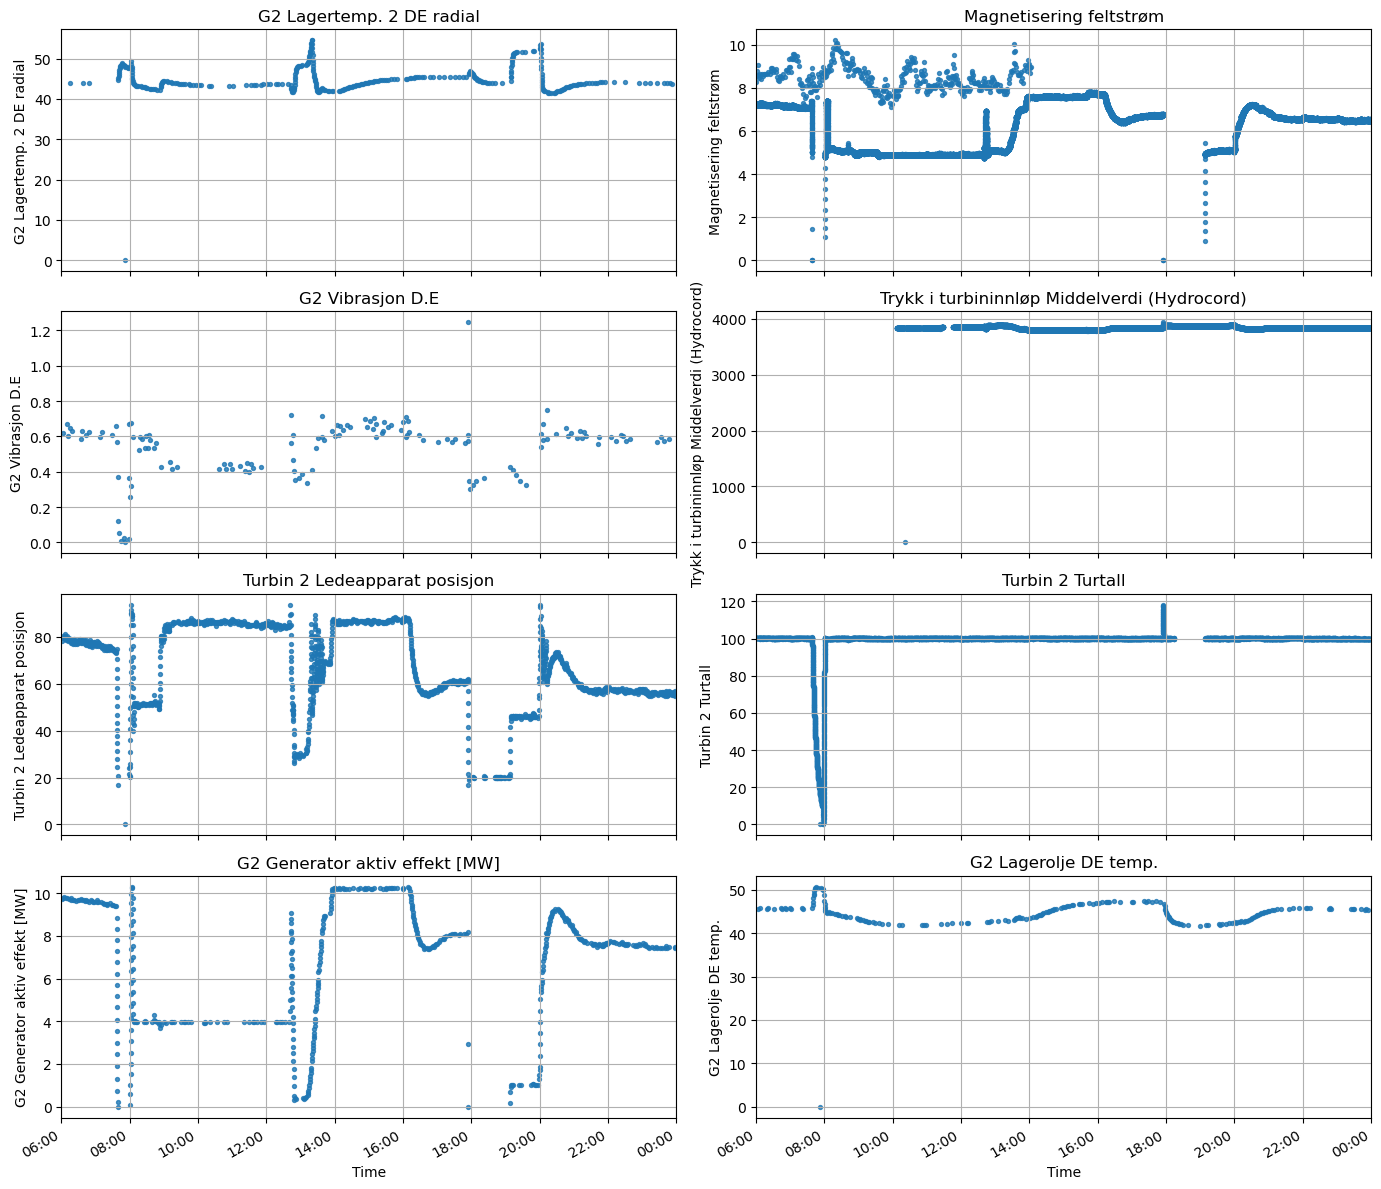

In [5]:
start_time = pd.Timestamp("2024-06-03 06:00:00")
end_time = start_time + pd.Timedelta(hours=18)

n_plots = len(dfs_raw)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i, df in enumerate(dfs_raw):
    signal_name = df.columns[1]

    df_plot = df[
        (df["Timestamp"] >= start_time) &
        (df["Timestamp"] < end_time)
    ]

    axes[i].scatter(df_plot["Timestamp"], df_plot[signal_name], s=8, alpha=0.8, rasterized=True)
    axes[i].set_xlim(start_time, end_time)
    axes[i].set_title(signal_name)
    axes[i].set_ylabel(signal_name)
    axes[i].grid(True)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

for ax in axes[:n_plots]:
    ax.set_xlabel("Time")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [12]:
# 1 weeks of 10s data points
n = 6*60*24*9
# Folder relevant signals
folder = "step_interpolation_10s/G2_relevant"
dfs, files = load_signal_data(n, folder)

In [103]:
# Remove negative values, and also zeros for temperature signals
for i, df in enumerate(dfs):
    signal_name = df.columns[1]
    mask = df[signal_name] >= 0

    if "temp" in signal_name.lower():
        mask &= df[signal_name] != 0

    dfs[i] = df[mask].copy()
    print(f"{signal_name}: removed {len(df) - len(dfs[i])} values")

G2 Vibrasjon D.E: removed 0 values
Trykk i turbininnløp Middelverdi (Hydrocord): removed 759 values
Turbin 2 Turtall: removed 0 values
G2 Lagertemp. 2 DE radial: removed 4 values
Magnetisering feltstrøm: removed 0 values
G2 Lagerolje DE temp.: removed 10 values
Turbin 2 Ledeapparat posisjon: removed 0 values
G2 Generator aktiv effekt [MW]: removed 0 values


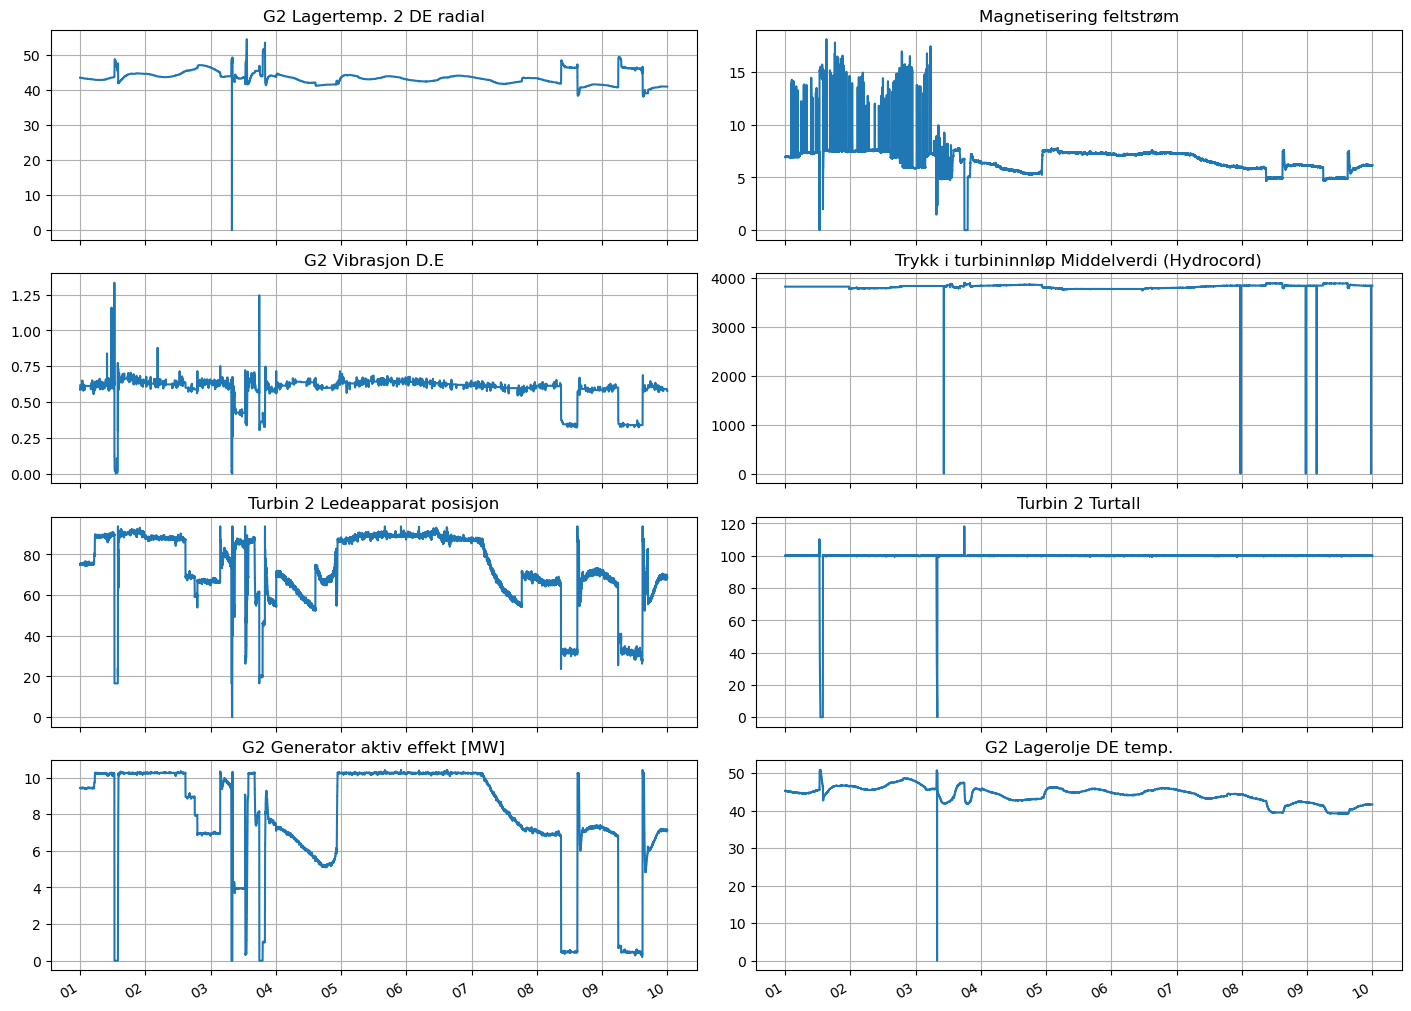

In [13]:
num_plots = len(dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 2.5 * num_rows),
    constrained_layout=True
)

axes = axes.flatten()

for ax, df in zip(axes, dfs):
    signal_name = df.columns[1]
    ax.plot(df["Timestamp"], df[signal_name])
    ax.set_title(signal_name)
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))

for ax in axes[num_plots:]:
    ax.remove()

fig.autofmt_xdate()
plt.show()

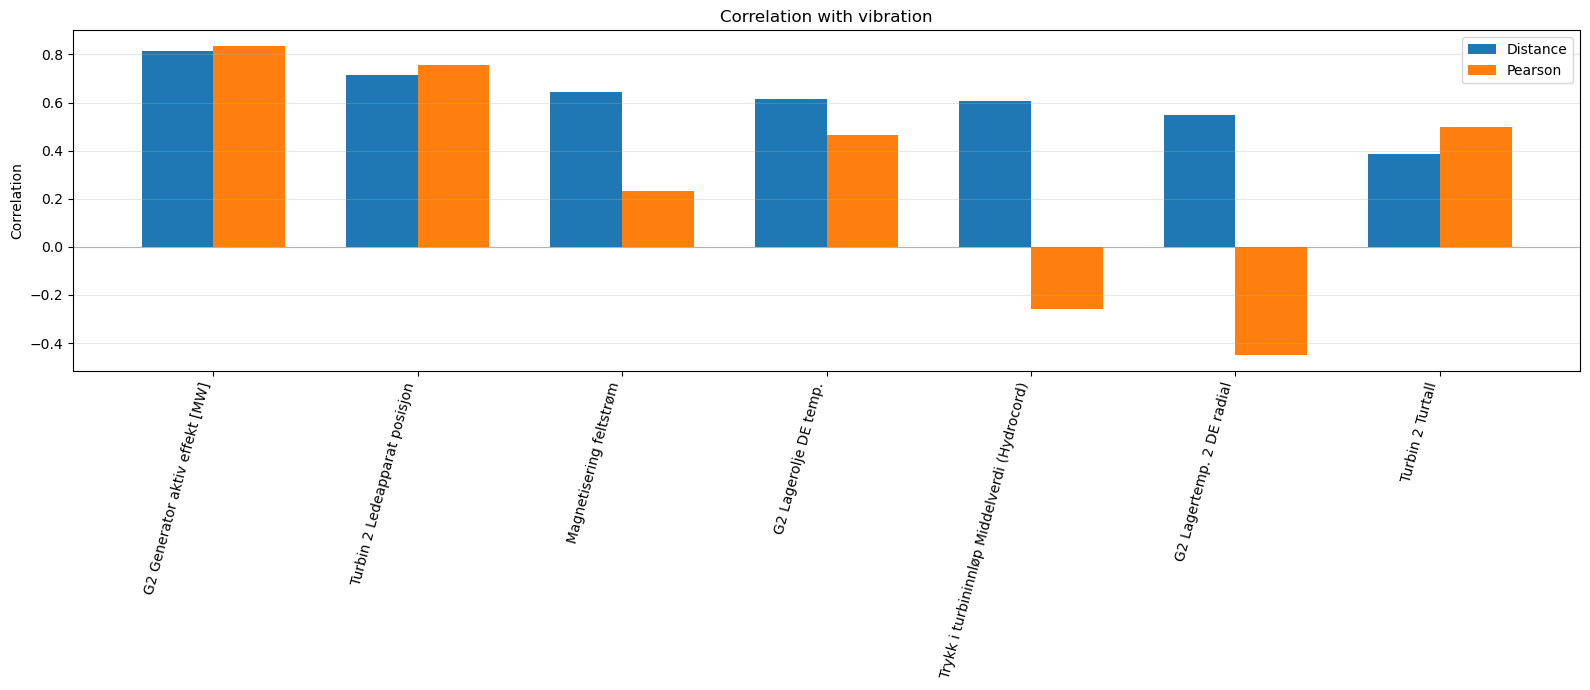

In [14]:
# Reference signal
vib_name = "G2 Vibrasjon D.E"
vib = next(df for df in dfs if vib_name in df.columns)

results = []

# Correlate every signal against vibration
for df in dfs:
    name = df.columns[1]
    if name == vib_name:
        continue

    # Align on timestamp
    data = pd.merge(vib[["Timestamp", vib_name]], df[["Timestamp", name]], on="Timestamp").dropna()
    if len(data) < 2:
        continue
    
    # Add a dictionary with the results for each signal
    results.append({
        "Signal": name,
        "Pearson": pearsonr(data[vib_name], data[name])[0],
        "Distance": dcor.distance_correlation(data[vib_name].to_numpy(), data[name].to_numpy())
    })

# Sort results
corr_df = pd.DataFrame(results).sort_values("Distance", ascending=False)

# Bar positions
x = np.arange(len(corr_df))
w = 0.35

# Plot
plt.figure(figsize=(16, 7))
plt.bar(x - w/2, corr_df["Distance"], width=w, label="Distance")
plt.bar(x + w/2, corr_df["Pearson"], width=w, label="Pearson")

plt.xticks(x, corr_df["Signal"], rotation=75, ha="right")
plt.ylabel("Correlation")
plt.title("Correlation with vibration")
plt.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
power_name = "G2 Generator aktiv effekt [MW]"
vib_name = "G2 Vibrasjon D.E"

power = next(df for df in dfs if power_name in df.columns).copy()
vib = next(df for df in dfs if vib_name in df.columns).copy()

# Signal for PELT
y = power[power_name].to_numpy()

# Fit PELT

algo = rpt.Pelt(model="l2").fit(y)
penalty = 2 * np.log(len(y))
bkps = algo.predict(pen=penalty)

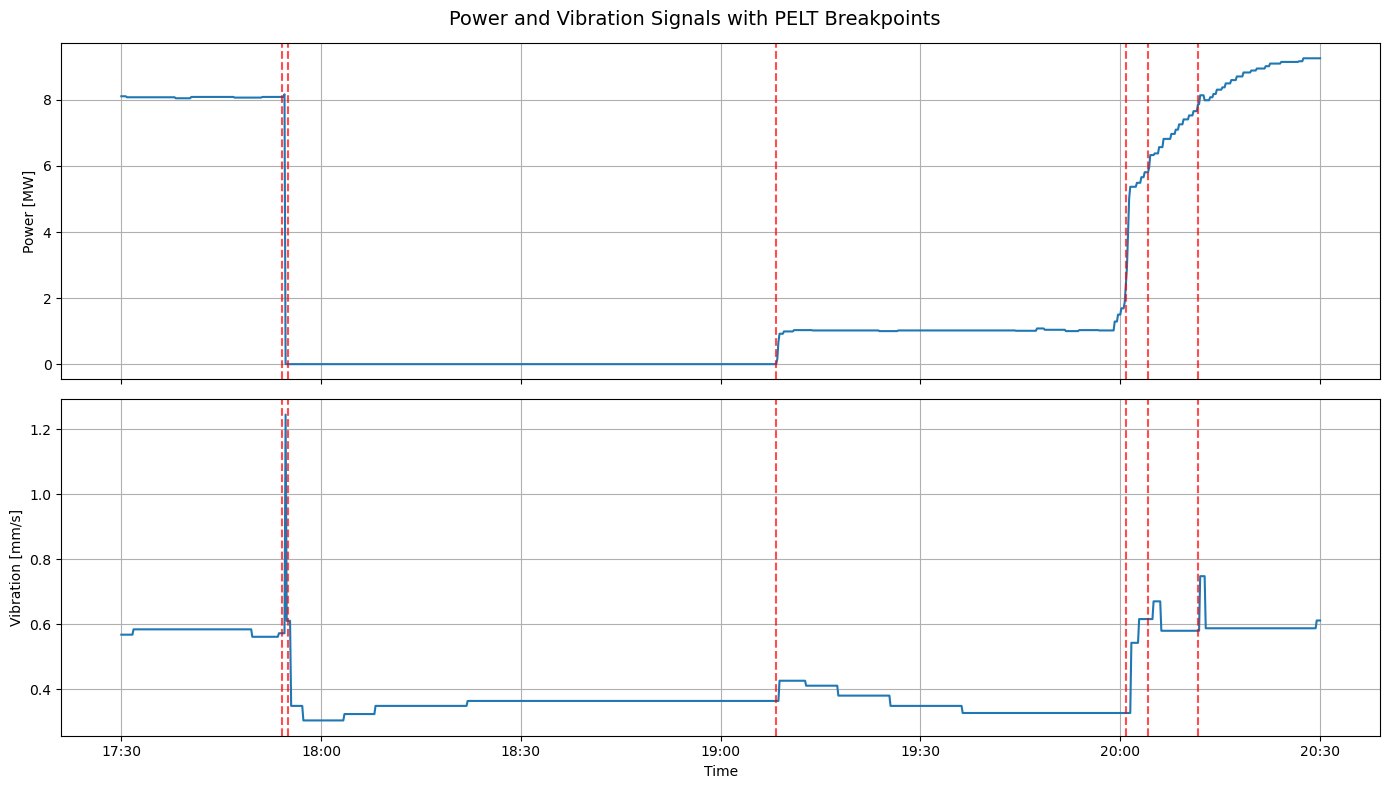

In [ ]:
plot_start = pd.Timestamp("2024-06-03 17:30:00")
plot_end = pd.Timestamp("2024-06-03 20:30:00")

power_plot = power[power["Timestamp"].between(plot_start, plot_end)]
vib_plot = vib[vib["Timestamp"].between(plot_start, plot_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Power and Vibration Signals with PELT Breakpoints", fontsize=14)

for ax, df, name, ylabel in zip(
    axes,
    [power_plot, vib_plot],
    [power_name, vib_name],
    ["Power [MW]", "Vibration [mm/s]"]
):
    if not df.empty:
        ax.plot(df["Timestamp"], df[name])
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.grid(True)

for b in bkps[:-1]:
    t = power["Timestamp"].iloc[b]
    if plot_start <= t <= plot_end:
        for ax in axes:
            ax.axvline(t, linestyle="--", alpha=0.7, color="red")

axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

In [34]:
print(power_plot.index.equals(vib_plot.index))
print(power_plot.index[:5])
print(vib_plot.index[:5])

False
Index([23580, 23581, 23582, 23583, 23584], dtype='int64')
Index([23581, 23582, 23583, 23584, 23585], dtype='int64')


In [123]:
# Build segments from breakpoints
segments = []
start = 0

for end in bkps:
    segment = power.iloc[start:end].copy()
    
    if len(segment) > 1:
        segments.append({
            "start_idx": start,
            "end_idx": end,
            "start_time": segment["Timestamp"].iloc[0],
            "end_time": segment["Timestamp"].iloc[-1],
            "mean": segment[power_name].mean(),
            "std": segment[power_name].std(),
            "length": len(segment)
        })
    
    start = end

segments_df = pd.DataFrame(segments)

print(segments_df.head())

   start_idx  end_idx          start_time            end_time       mean  \
0          0     1950 2024-06-01 00:00:00 2024-06-01 05:24:50   9.438477   
1       1950     4540 2024-06-01 05:25:00 2024-06-01 12:36:30  10.214127   
2       4540     4545 2024-06-01 12:36:40 2024-06-01 12:37:20   4.088000   
3       4545     5015 2024-06-01 12:37:30 2024-06-01 13:55:40   0.007787   
4       5015     5035 2024-06-01 13:55:50 2024-06-01 13:59:00   3.990000   

        std  length  
0  0.063817    1950  
1  0.028472    2590  
2  5.597724       5  
3  0.110062     470  
4  0.752512      20  
